<a href="https://colab.research.google.com/github/marinarhianna/python-tutorials-2026/blob/main/python_session2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2 🪐
This notebook will introduce you to Python code and libraries used by real astromers to study exoplanets and star data.

---


## Part 1: Recap

Let's explore how we can use Python to handle exoplanet data.

Last notebook, we saw how to create variables. A couple examples of this has been done in the cell below.

**EXERCISE:** The orbital period is 1.63 days. Create a variable to store it.

In [ ]:
# defining some information about an exoplanet
planet_name = "WASP-5b"
planet_radius = 1.18
##### REPLACE WITH YOUR CODE #####

In [ ]:
#@title Example solution
orbital_period = 1.63

**EXERCISE:** Write some code that would output a sentence similar to:
"The name of the planet is WASP-5b", but instead one for the radius and one for the period.

Hint: Remember to be careful with commas and speech marks when using the `print` function!

In [ ]:
###############################
### REPLACE WITH YOUR CODE ###
###############################

In [ ]:
#@title Example Solution
# print out some facts
print("The planet is called", planet_name)
print("Its radius is", planet_radius, "times the radius of Jupiter.")
print("It goes around its star every", orbital_period, "days.")



---


## Part 2: Using a special exoplanets library 📚

`lightkurve` is a Python library of functions used by real astronomers to analyse transiting exoplanet data.

Some libraries that you saw in the last notebook, like `numpy`, are more common and so Google Colab already has them installed and ready to import into the notebook.

`lightkurve` is more niche so we need to install it ourselves before we can import it:

In [ ]:
!pip install lightkurve --quiet

Now we can import the library and specify a particular function that we want from it:

In [ ]:
from lightkurve import search_lightcurve

We can use `lightkurve` to search and download the light curve of a specific planet.

There are two functions that help us do this from lightkurve:

* `search_lightcurve()`
* `.download()`

Let's name and create a variable to store the light curve in, and then use these functions together to search and download it there.


In [ ]:
# name a variable, search the database for a specific planet, and download the light curve
lc = search_lightcurve("Kepler-6", mission='Kepler').download()

Last notebook we met a library called matplotlib which helped us to easily plot graphs.

lightkurve has an inbuilt plotting function that is even easier to use: `.plot()`

We can use it by just adding it to the end of the name of the variable we defined to store our downloaded light curve in:

In [ ]:
# plot our light curve
lc.plot()



---


**EXERCISE:**
Write down anything you notice about this light curve that we have downloaded. Does it look how you expected? What can you see that indicates an exoplanet. What is unusual? Put your hand up so we can talk through these things together.


---



**HOW TO "CLEAN" A LIGHT CURVE**
`lightkurve` has functions that help us to clean up a light curve, making the data easier to analyse.

This light curve has a few random large upward spikes that don't contain useful planetary info. These outliers just add mess and make the transit dips harder to see.

We can remove these by using a function called `.remove_outliers()`.
This function requires us to set a `sigma=` value inside it.




---

**EXERCISE:**
The cell below creates a new light curve variable to store our clean one that we are using the function on.

* Pick a number between 10 and 1, and set this to the sigma= value inside the brackets.
* In the same cell on a new line, plot the new light curve and add a comment above the code.
* Note down what that sigma= value did, and try out a range of other numbers between 1 and 10.

Note: we want to preserve the shape and prominence of the downward dips, that tell us important info about the exoplanet, but we want to remove the upward ones as much as possible. Try to find the sweet spot!

---



In [ ]:
# removing outliers
new_lc = lc.remove_outliers(sigma=)

###############################
### REPLACE WITH YOUR CODE ###
###############################

In [ ]:
#@title Example Solution
# plot the new light curve
new_lc.plot()

Notice how we define a new variable, `new_lc`, for the cleaned up light curve, and set this equal to the function performing on the old variable, `lc`.



---
You may have noticed the numbers on the y-axis are pretty huge and in confusing units. Astronomers will often change the y-axis units to be centred around a baseline of 1. This is called normalizing.

`lightkurve` has a ready-made function to do this, called `.normalize()`.

**EXERCISE:**
* Define a new variable for the normalized light curve with its own name, and call the `.normalize()` function on the previous cleaned light curve.
* Plot your new light curve.

In [ ]:
###############################
### REPLACE WITH YOUR CODE ###
###############################

In [ ]:
#@title Example Solution
# normalize data with function, store normalized light curve in another name
norm_lc = new_lc.normalize()

# plot normalized light curve
norm_lc.plot()


---
**EXERCISE**:
Estimate the *period* of the planet, ie. how many days it takes for the planet to do one lap around its star.
You can do this by eye from the plotted light curve, or with a ruler if needed. Make a note of it, to 2 decimal places.

If you are struggling, just put your hand up to ask for a hint!

---

**Folding a light curve**.
* In these light curve plots we can see many dips. Sometimes, astronomers want to zoom in on a dip to see the shape of it more clearly.

* We don't want to choose just one dip at random to zoom in on, because what if this dip has some outlier?

* Instead, we can use Python to layer all the dips on top of each other, a bit like taking an average, but for a graph.

* This is called folding the light curve and it helps us to separate the transits from the noisy baseline.

---



**HARDER EXERCISE**:
lightkurve has a function for this called `.fold()`, which takes an input `period=` which we need to set. The structure of this is the same as with the function `remove_outliers()` and the input `sigma=` which we had to set earlier.

Luckily, you already estimated the planet's period earlier!

* Create and plot a folded light curve by using the function.

Hint: remember the structure we used previously!

In [ ]:
###############################
### REPLACE WITH YOUR CODE ###
###############################

If your plot looks weird, put your hand up and we can chat about why.

In [ ]:
#@title Example Solution:

# fold light curve, store in another variable
folded_lc = norm_lc.fold(period=3.23)

# plot folded light curve
folded_lc.plot()



---

## Part 3: A closer look at another planet 🪐

HD 209458b is a famous exoplanet in the Pegasus constellation that orbits a solar-like star.

Some people informally call it Osiris.

The period is 3.52 days.

Let's take a look at it!

* Use the `search_lightcurve` function to download the light curve for `HD 209458`, observed by the `TESS` mission.
* Remember to give it a unique name.

In [ ]:
###############################
### REPLACE WITH YOUR CODE ###
###############################

In [ ]:
# @title Solution:

# download light curve for HD 209458
os_lc = search_lightcurve("HD 209458", mission='TESS').download()
os_lc.plot()

* Do you see any significant upward spike outliers that need to be removed? If so, implement the `.remove_outliers()` function. If not, you can skip that step.

---

Notice that the baseline is wavey, as if it is slightly oscillating. This is due to that star having more activity than the other, and it makes spotting transit dips harder.

Lightkurve has a function to deal with this, called `.flatten()` which applies a smoothing filter.

* Using the same structure as before, make a new plot of the flattened light curve by using this function.

In [ ]:
###############################
### REPLACE WITH YOUR CODE ###
###############################

In [ ]:
#@title Solution:
flat_lc = os_lc.flatten()
flat_lc.plot()

**EXERCISE**: Fold the flattened light curve over the period and plot it.

In [ ]:
###############################
### REPLACE WITH YOUR CODE ###
###############################

In [ ]:
#@title Solution:
fold_lc= flat_lc.fold(period=3.52)
fold_lc.plot()

The radius of this star is 1.2 Solar Radii.

Below is an equation which links the depth of the transit dip to the planetary radius and the stellar radius.

Python can be used like a calculator!

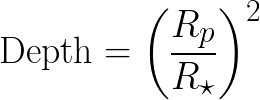

* Calculate the planetary radius in Solar Radii units.
* Then convert this to Jupiter Radii units, where 1 Solar Radius = 9.73 Jupiter Radii.

The depth will be the baseline minus how far down the dip goes.  

Hint: To use a square root in Python, you can import the `numpy` module as `np` and use `np.sqrt()`

In [ ]:
###############################
### REPLACE WITH YOUR CODE ###
###############################

In [ ]:
#@title Example Solution:
import numpy as np

depth = 0.01

radius_ratio = np.sqrt(depth)

planet_radius_solar = radius_ratio * 1.2

planet_radius_jup = planet_radius_solar * 9.73

print("The planetary radius is", planet_radius_jup, "times the radius of Jupiter.")

## Part 4: Explore the tools yourself!

Above you have seen various ways to deal with light curve data such as:
* Removing outliers
* Flattening
* Folding
* Normalizing

Not every light curve will need all of these processes, and part of being an astronomer is looking at the raw data and deciding what processing needs to be done to analyse the curve.

Google "NASA Eyes on Exoplanets" and click the first link to take you to a tool which allows you to explore a vast variety of exoplanets.

Play around with the tool and explore any planets that look interesting to you by:
* Confirming the name of the planet
* Checking what instrument it was observed by (Kepler or TESS, or both!)
* Use the search_lightcurve tool to download the data.
* Look at the raw curve and decide what will help to see the transits better.

For example:
* If the baseline is wavey, flatten it!
* If there are many upward spikes, remove the outliers!

Play around with this tool to explore what different light curves look like. Some will be more straightforward, others may be complex and difficult to handle! If you see a lightcurve that looks like a nightmare, feel free to move onto another, or discuss what might be causing the effect.

Note: The `.flatten()` function will often work on its own, but in some cases it will need extra parameters put inside the brackets. If you are finding that it isn't working the way you want it to, try putting in the brackets:

`.flatten(window_length=101)` or `.flatten(window_length=201)`

If those don't work, you could try other numbers like 301 or even 1001. The window length is how the flattening filter knows to remove trends: a longer window will remove slower trends, while a shorter window will remove faster trends.

In [ ]:
#################################
### PLAY AROUND WITH THE CODE ###
#################################